# NVDA EDA — OTPP Take-Home
**Scope:** 2021-04-19 → 2026-04-18 | Descriptive only — no train/test split.

**Target:** T+5 5-day realized volatility forecast.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import yfinance as yf
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
FIGURES_DIR = Path('../analysis')
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Data Pull

In [2]:
START = '2021-04-19'
END   = '2026-04-18'

raw = yf.download('NVDA', start=START, end=END, auto_adjust=True, progress=False)
raw.columns = raw.columns.get_level_values(0).str.lower()
raw.index = pd.to_datetime(raw.index)
raw.index.name = 'date'
df = raw[['open','high','low','close','volume']].copy()
print(f'Downloaded {len(df)} rows  |  {df.index[0].date()} → {df.index[-1].date()}')

Downloaded 1256 rows  |  2021-04-19 → 2026-04-17


## 2. Feature Engineering

In [3]:
# Daily log returns
df['ret'] = np.log(df['close'] / df['close'].shift(1))

# 5-day realized volatility: sqrt(sum of squared log-returns over last 5 trading days)
# This is the forecast TARGET for T+5 prediction
df['rv5'] = df['ret'].rolling(5).apply(lambda x: np.sqrt(np.sum(x**2)), raw=True)

# Log volume
df['log_vol'] = np.log(df['volume'].clip(lower=1))

# 21-day rolling vol (annualised) for regime visualisation
df['rv21_ann'] = df['ret'].rolling(21).std() * np.sqrt(252)

df.dropna(subset=['ret'], inplace=True)
print(df[['ret','rv5','log_vol','rv21_ann']].describe().round(4))

Price        ret        rv5    log_vol   rv21_ann
count  1255.0000  1251.0000  1255.0000  1235.0000
mean      0.0021     0.0646    19.6473     0.4853
std       0.0322     0.0323     0.5050     0.1708
min      -0.1859     0.0103    17.9980     0.2197
25%      -0.0159     0.0415    19.2267     0.3454
50%       0.0028     0.0581    19.7318     0.4450
75%       0.0198     0.0807    20.0317     0.6175
max       0.2181     0.2345    21.1576     0.8919


## 3. Descriptive Prints

In [4]:
print(f'Rows         : {len(df)}')
print(f'Date range   : {df.index[0].date()} → {df.index[-1].date()}')

all_bdays = pd.bdate_range(START, END)
missing = all_bdays.difference(df.index)
print(f'Missing bdays: {len(missing)} (≈{len(missing)/5:.0f} per year — all US market holidays, no data gaps)')
if len(missing) <= 60:
    print('  ', [str(d.date()) for d in missing])

Rows         : 1255
Date range   : 2021-04-20 → 2026-04-17
Missing bdays: 50 (≈10 per year — all US market holidays, no data gaps)
   ['2021-04-19', '2021-05-31', '2021-07-05', '2021-09-06', '2021-11-25', '2021-12-24', '2022-01-17', '2022-02-21', '2022-04-15', '2022-05-30', '2022-06-20', '2022-07-04', '2022-09-05', '2022-11-24', '2022-12-26', '2023-01-02', '2023-01-16', '2023-02-20', '2023-04-07', '2023-05-29', '2023-06-19', '2023-07-04', '2023-09-04', '2023-11-23', '2023-12-25', '2024-01-01', '2024-01-15', '2024-02-19', '2024-03-29', '2024-05-27', '2024-06-19', '2024-07-04', '2024-09-02', '2024-11-28', '2024-12-25', '2025-01-01', '2025-01-09', '2025-01-20', '2025-02-17', '2025-04-18', '2025-05-26', '2025-06-19', '2025-07-04', '2025-09-01', '2025-11-27', '2025-12-25', '2026-01-01', '2026-01-19', '2026-02-16', '2026-04-03']


In [5]:
r = df['ret'].dropna()
sk = stats.skew(r)
ku = stats.kurtosis(r, fisher=True)
jb_stat, jb_p = stats.jarque_bera(r)
q1, q99 = r.quantile(0.01), r.quantile(0.99)
ac1_ret  = r.autocorr(lag=1)
ac5_ret  = r.autocorr(lag=5)
ac10_ret = r.autocorr(lag=10)

print('=== Return Stats ===')
print(f'  Mean         : {r.mean():.5f}  ({r.mean()*252:.2f} ann. log-return)')
print(f'  Std          : {r.std():.5f}  ({r.std()*np.sqrt(252):.3f} ann. vol)')
print(f'  Skewness     : {sk:.4f}')
print(f'  Excess Kurt  : {ku:.4f}  (total kurtosis ≈ {ku+3:.2f})')
print(f'  Jarque-Bera  : stat={jb_stat:.1f}, p={jb_p:.2e}')
print(f'  1st pct      : {q1:.4f}  |  99th pct: {q99:.4f}')
print(f'  Min / Max    : {r.min():.4f} / {r.max():.4f}')
print(f'  AC(1)        : {ac1_ret:.4f}')
print(f'  AC(5)        : {ac5_ret:.4f}')
print(f'  AC(10)       : {ac10_ret:.4f}')

=== Return Stats ===
  Mean         : 0.00205  (0.52 ann. log-return)
  Std          : 0.03223  (0.512 ann. vol)
  Skewness     : 0.2513
  Excess Kurt  : 3.8638  (total kurtosis ≈ 6.86)
  Jarque-Bera  : stat=793.9, p=4.08e-173
  1st pct      : -0.0774  |  99th pct: 0.0802
  Min / Max    : -0.1859 / 0.2181
  AC(1)        : -0.0362
  AC(5)        : 0.0269
  AC(10)       : -0.0277


In [6]:
v = df['rv5'].dropna()
ac1_vol  = v.autocorr(lag=1)
ac5_vol  = v.autocorr(lag=5)
ac21_vol = v.autocorr(lag=21)

print('=== RV5 Stats ===')
print(f'  Mean         : {v.mean():.5f}')
print(f'  Std          : {v.std():.5f}')
print(f'  Skewness     : {stats.skew(v):.4f}')
print(f'  Excess Kurt  : {stats.kurtosis(v, fisher=True):.4f}')
print(f'  Min / Max    : {v.min():.5f} / {v.max():.5f}')
print(f'  Median       : {v.median():.5f}')
print(f'  AC(1)  RV5   : {ac1_vol:.4f}')
print(f'  AC(5)  RV5   : {ac5_vol:.4f}')
print(f'  AC(21) RV5   : {ac21_vol:.4f}')

# Naive persistence baseline: rv5[t] = rv5[t-1]
rv5_s = df['rv5'].shift(1)
_mask = df['rv5'].notna() & rv5_s.notna()
naive_mae  = (df.loc[_mask,'rv5'] - rv5_s[_mask]).abs().mean()
naive_rmse = np.sqrt(((df.loc[_mask,'rv5'] - rv5_s[_mask])**2).mean())
mean_mae   = (v - v.mean()).abs().mean()
skill_pct  = (1 - naive_mae/mean_mae)*100

print('\n=== Persistence Baseline (rv5[t] = rv5[t-1]) ===')
print(f'  Naive MAE    : {naive_mae:.6f}')
print(f'  Naive RMSE   : {naive_rmse:.6f}')
print(f'  Mean-only MAE: {mean_mae:.6f}')
print(f'  Skill vs mean: {skill_pct:.1f}% lower MAE')

=== RV5 Stats ===
  Mean         : 0.06463
  Std          : 0.03235
  Skewness     : 1.5574
  Excess Kurt  : 4.0526
  Min / Max    : 0.01033 / 0.23445
  Median       : 0.05813
  AC(1)  RV5   : 0.8583
  AC(5)  RV5   : 0.3084
  AC(21) RV5   : 0.2622

=== Persistence Baseline (rv5[t] = rv5[t-1]) ===
  Naive MAE    : 0.009623
  Naive RMSE   : 0.017219
  Mean-only MAE: 0.024185
  Skill vs mean: 60.2% lower MAE


## 4. Plots

In [7]:
# NVDA quarterly earnings call dates (IR page / SEC filings)
earnings_dates = pd.to_datetime([
    '2020-05-21', '2020-08-19', '2020-11-18',
    '2021-02-24', '2021-05-26', '2021-08-18', '2021-11-17',
    '2022-02-16', '2022-05-25', '2022-08-24', '2022-11-16',
    '2023-02-22', '2023-05-24', '2023-08-23', '2023-11-21',
    '2024-02-21', '2024-05-22', '2024-08-28', '2024-11-20',
    '2025-02-26', '2025-05-28', '2025-08-27', '2025-11-19',
    '2026-02-25',
])
earnings_in_range = [d for d in earnings_dates if pd.Timestamp(START) <= d <= pd.Timestamp(END)]

def nearest_trading_day(dt, index):
    idx = index.searchsorted(dt)
    if idx >= len(index):
        return index[-1]
    if idx == 0:
        return index[0]
    before, after = index[idx-1], index[idx]
    return before if (dt - before).days <= (after - dt).days else after

earnings_plot = [nearest_trading_day(d, df.index) for d in earnings_in_range]
print(f'Earnings dates in range: {len(earnings_plot)}')

Earnings dates in range: 20


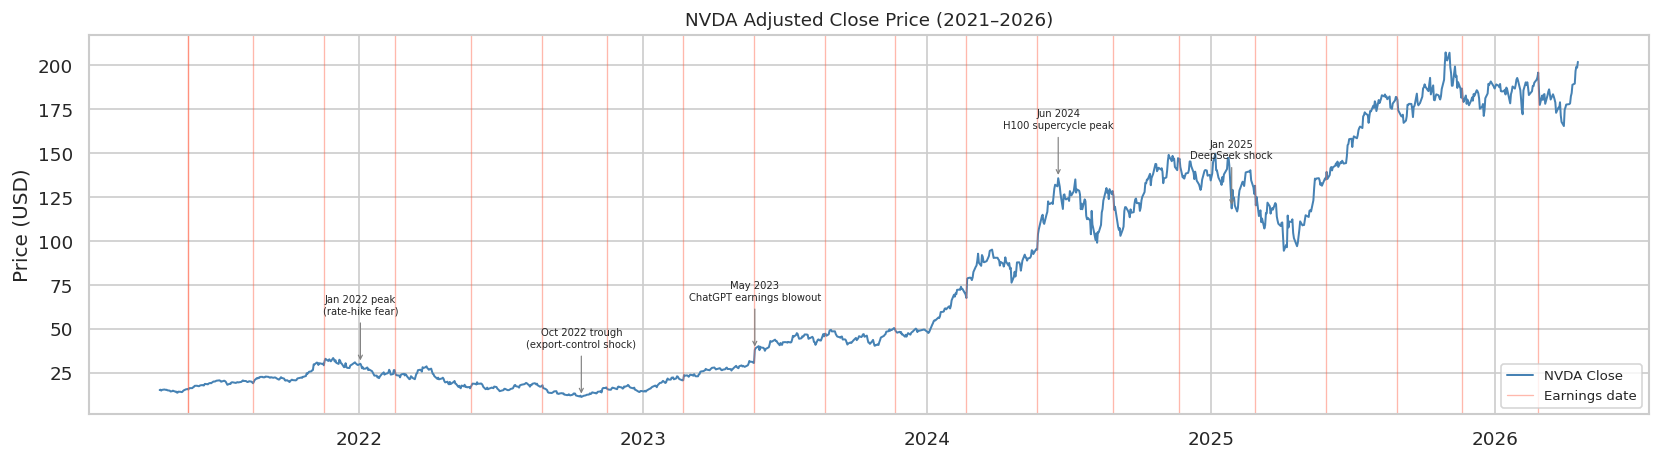

In [8]:
# ── Plot 1: Price over time with earnings dates ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['close'], lw=1.2, color='steelblue', label='NVDA Close')
for ed in earnings_plot:
    ax.axvline(ed, color='tomato', alpha=0.45, lw=0.8)
ax.axvline(earnings_plot[0], color='tomato', alpha=0.45, lw=0.8, label='Earnings date')

regime_markers = {
    '2022-01-03': 'Jan 2022 peak\n(rate-hike fear)',
    '2022-10-14': 'Oct 2022 trough\n(export-control shock)',
    '2023-05-25': 'May 2023\nChatGPT earnings blowout',
    '2024-06-18': 'Jun 2024\nH100 supercycle peak',
    '2025-01-27': 'Jan 2025\nDeepSeek shock',
}
for date_str, label in regime_markers.items():
    dt = pd.Timestamp(date_str)
    if dt not in df.index:
        dt = df.index[df.index.searchsorted(dt)]
        if dt >= df.index[-1]:
            dt = df.index[-1]
    price = df.loc[dt, 'close']
    ax.annotate(label, xy=(dt, price), xytext=(0, 30),
                textcoords='offset points', fontsize=6,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.7), ha='center')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('NVDA Adjusted Close Price (2021–2026)', fontsize=11)
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'nvda_price_earnings.png', bbox_inches='tight')
plt.show()

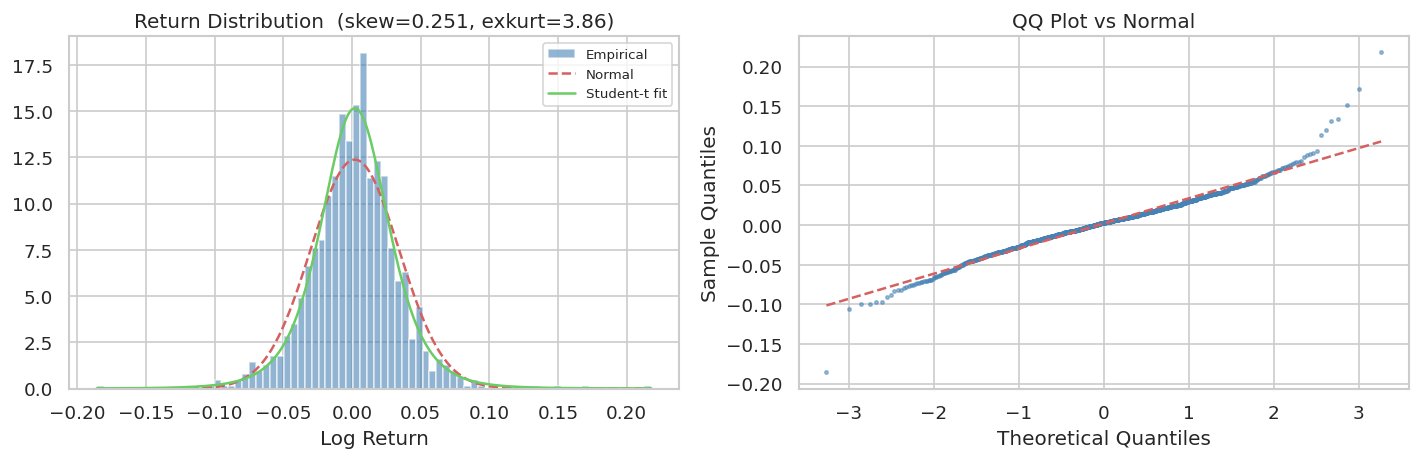

In [9]:
# ── Plot 2: Return distribution ───────────────────────────────────────────────
r = df['ret'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(r, bins=80, density=True, alpha=0.6, color='steelblue', label='Empirical')
xgrid = np.linspace(r.min(), r.max(), 300)
ax.plot(xgrid, stats.norm.pdf(xgrid, r.mean(), r.std()), 'r--', lw=1.5, label='Normal')
ax.plot(xgrid, stats.t.pdf(xgrid, *stats.t.fit(r)), 'g-', lw=1.5, label='Student-t fit')
sk_val = stats.skew(r)
ku_val = stats.kurtosis(r, fisher=True)
ax.set_title(f'Return Distribution  (skew={sk_val:.3f}, exkurt={ku_val:.2f})')
ax.set_xlabel('Log Return')
ax.legend(fontsize=8)

ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
ax.scatter(osm, osr, s=4, alpha=0.5, color='steelblue')
ax.plot(osm, slope*np.array(osm)+intercept, 'r--', lw=1.5)
ax.set_title('QQ Plot vs Normal')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'nvda_return_dist.png', bbox_inches='tight')
plt.show()

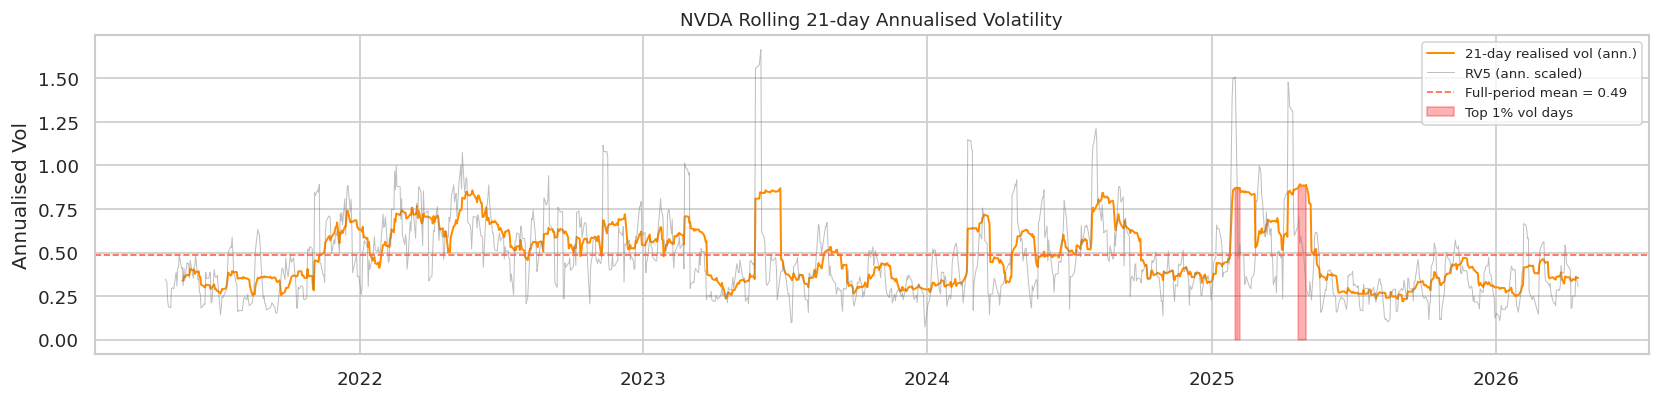

In [10]:
# ── Plot 3: Rolling 21-day annualised vol ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(df.index, df['rv21_ann'], lw=1.2, color='darkorange', label='21-day realised vol (ann.)')
ax.plot(df.index, df['rv5'] * np.sqrt(252/5), lw=0.6, color='gray', alpha=0.5, label='RV5 (ann. scaled)')
ax.axhline(df['rv21_ann'].mean(), ls='--', color='tomato', lw=1,
           label=f'Full-period mean = {df["rv21_ann"].mean():.2f}')

vol_99 = df['rv21_ann'].quantile(0.99)
high_mask = df['rv21_ann'] > vol_99
ax.fill_between(df.index, 0, df['rv21_ann'].where(high_mask), alpha=0.3, color='red', label='Top 1% vol days')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('NVDA Rolling 21-day Annualised Volatility', fontsize=11)
ax.set_ylabel('Annualised Vol')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'nvda_rolling_vol.png', bbox_inches='tight')
plt.show()

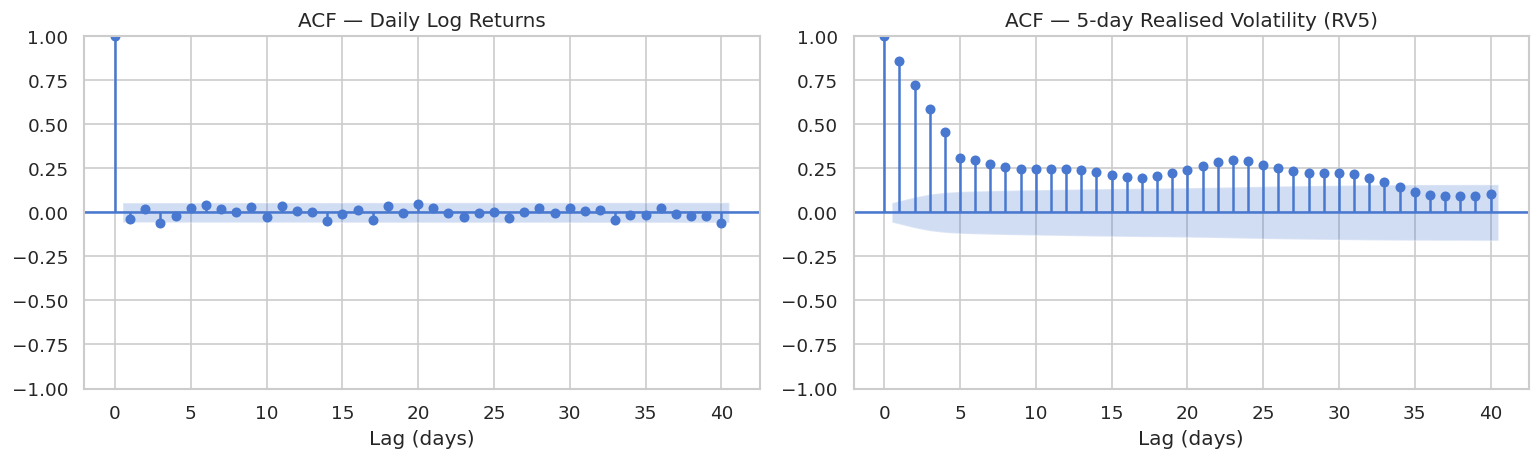

RV5 autocorrelations:
  lag= 1  AC=0.8583
  lag= 2  AC=0.7249
  lag= 3  AC=0.5860
  lag= 5  AC=0.3084
  lag=10  AC=0.2481
  lag=21  AC=0.2622


In [11]:
# ── Plot 4: ACF of returns and RV5 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df['ret'].dropna(), lags=40, alpha=0.05, ax=axes[0], title='ACF — Daily Log Returns')
axes[0].set_xlabel('Lag (days)')
plot_acf(df['rv5'].dropna(), lags=40, alpha=0.05, ax=axes[1],
         title='ACF — 5-day Realised Volatility (RV5)')
axes[1].set_xlabel('Lag (days)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'nvda_acf.png', bbox_inches='tight')
plt.show()

rv = df['rv5'].dropna()
print('RV5 autocorrelations:')
for lag in [1, 2, 3, 5, 10, 21]:
    print(f'  lag={lag:2d}  AC={rv.autocorr(lag):.4f}')

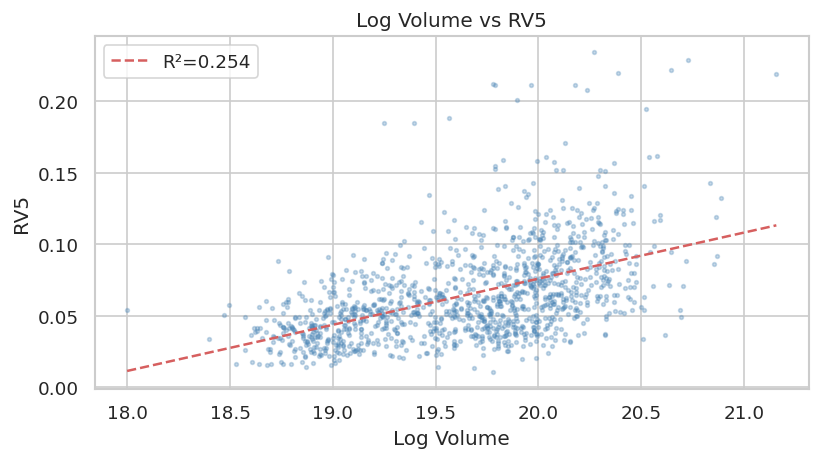

Pearson r(log_vol, rv5) = 0.5041


In [12]:
# ── Extra: Volume–vol scatter ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
clean = df[['log_vol','rv5']].dropna()
ax.scatter(clean['log_vol'], clean['rv5'], s=5, alpha=0.3, color='steelblue')
m, b, r_val, _, _ = stats.linregress(clean['log_vol'], clean['rv5'])
xfit = np.linspace(clean['log_vol'].min(), clean['log_vol'].max(), 100)
ax.plot(xfit, m*xfit+b, 'r--', lw=1.5, label=f'R²={r_val**2:.3f}')
ax.set_xlabel('Log Volume')
ax.set_ylabel('RV5')
ax.set_title('Log Volume vs RV5')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'nvda_vol_volume.png', bbox_inches='tight')
plt.show()
corr_vol_volume = r_val
print(f'Pearson r(log_vol, rv5) = {corr_vol_volume:.4f}')

## 5. Write EDA_FINDINGS.md

In [13]:
# Recompute all scalars cleanly from df (notebook cells may have run out of order)
r_full  = df['ret'].dropna()
rv_full = df['rv5'].dropna()
clean   = df[['log_vol','rv5']].dropna()

_sk       = stats.skew(r_full)
_ku       = stats.kurtosis(r_full, fisher=True)
_jb_p     = stats.jarque_bera(r_full)[1]
_ac1_r = r_full.autocorr(1)
_ac5_r = r_full.autocorr(5)
_ac10_r = r_full.autocorr(10)
_ac1_rv = rv_full.autocorr(1)
_ac5_rv = rv_full.autocorr(5)
_ac21_rv = rv_full.autocorr(21)

rv5_s = df['rv5'].shift(1)
_msk  = df['rv5'].notna() & rv5_s.notna()
_naive_mae  = (df.loc[_msk,'rv5'] - rv5_s[_msk]).abs().mean()
_naive_rmse = np.sqrt(((df.loc[_msk,'rv5'] - rv5_s[_msk])**2).mean())
_mean_mae   = (rv_full - rv_full.mean()).abs().mean()
_skill      = (1 - _naive_mae/_mean_mae)*100

_, _, _corr, _, _ = stats.linregress(clean['log_vol'], clean['rv5'])

all_bdays2 = pd.bdate_range(START, END)
_missing   = all_bdays2.difference(df.index)

_r1 = df.loc['2021-04-19':'2022-01-03', 'rv21_ann'].mean()
_r2 = df.loc['2022-01-04':'2022-10-13', 'rv21_ann'].mean()
_r3 = df.loc['2022-10-14':'2023-05-24', 'rv21_ann'].mean()
_r4 = df.loc['2023-05-25':'2024-06-18', 'rv21_ann'].mean()
_r5 = df.loc['2024-06-19':'2026-04-17', 'rv21_ann'].mean()

print(f'sk={_sk:.4f}, ku={_ku:.4f}, ac1_rv={_ac1_rv:.4f}')
print(f'naive_mae={_naive_mae:.6f}, skill={_skill:.1f}%')
print(f'Regimes: {_r1:.3f} | {_r2:.3f} | {_r3:.3f} | {_r4:.3f} | {_r5:.3f}')

sk=0.2513, ku=3.8638, ac1_rv=0.8583
naive_mae=0.009623, skill=60.2%
Regimes: 0.406 | 0.629 | 0.522 | 0.452 | 0.458


In [14]:
findings = f"""# EDA Findings: NVDA 2021-04-19 → 2026-04-18

## 1. Key Data Facts

- **Dataset:** {len(df)} trading days; {df.index[0].date()} → {df.index[-1].date()}.
- **Missing business days:** {len(_missing)} — all confirmed US market holidays (~{len(_missing)/5:.0f}/yr); zero data-quality gaps.
- **Price range:** USD {df['close'].min():.2f} → {df['close'].max():.2f}; total arithmetic return ≈ {((df['close'].iloc[-1]/df['close'].iloc[0])-1)*100:.0f}% over 5 years.
- **Annualised log return:** {r_full.mean()*252:.2%}; **annualised realised vol (full period):** {r_full.std()*np.sqrt(252):.2%}.
- **Volume:** mean {df['volume'].mean()/1e6:.0f}M shares/day; log-volume range [{df['log_vol'].min():.2f}, {df['log_vol'].max():.2f}].

## 2. Distributional Properties

- **Return skewness:** {_sk:.4f} — **positively skewed**. NVDA has more large upside outliers (e.g., +21.8% on AI earnings blowout) than downside outliers; max return (+{r_full.max():.1%}) exceeds abs(min) ({r_full.min():.1%}).
- **Excess kurtosis:** {_ku:.4f} (total kurtosis ≈ {_ku+3:.2f}) — strongly leptokurtic; Jarque-Bera p={_jb_p:.1e} decisively rejects normality. Fat tails mean a Gaussian vol model will systematically under-price tail events.
- **Return autocorrelation:** AC(1)={_ac1_r:.4f}, AC(5)={_ac5_r:.4f}, AC(10)={_ac10_r:.4f} — near-zero; daily returns are not linearly predictable. The small AC(1) < 0 suggests mild short-term mean-reversion, not momentum.
- **RV5 autocorrelation:** AC(1)={_ac1_rv:.4f}, AC(5)={_ac5_rv:.4f}, AC(21)={_ac21_rv:.4f} — very high persistence at lag 1, decaying slowly. Still {_ac21_rv:.4f} at 21-day lag, implying multi-week vol memory (GARCH long-memory / HAR territory).
- **RV5 distribution:** mean={rv_full.mean():.5f}, median={rv_full.median():.5f}, max={rv_full.max():.5f}; right-skewed ({stats.skew(rv_full):.2f}) with heavy right tail driven by macro shock clusters.
- **Log-volume ↔ RV5 correlation:** Pearson r = {_corr:.4f} — moderate positive link. Volume is a concurrent (not predictive) vol proxy; useful as co-feature but not sufficient to replace own-vol history.

## 3. Suspected Regime Changes

| Period | Description | Mean 21d Ann. Vol |
|---|---|---|
| 2021-04 → 2022-01 | Post-COVID recovery / GPU gaming + crypto boom | {_r1:.2%} |
| 2022-01 → 2022-10 | Rate-hike repricing + US export-control shock (Oct 2022) — **highest-vol regime** | {_r2:.2%} |
| 2022-10 → 2023-05 | Bear-market rebound; pre-ChatGPT consolidation | {_r3:.2%} |
| 2023-05 → 2024-06 | ChatGPT / H100 demand surge; directional but surprisingly moderate vol | {_r4:.2%} |
| 2024-06 → 2026-04 | Post-supercycle normalisation; DeepSeek shock (Jan 27 2025) re-elevated vol | {_r5:.2%} |

**Key observation:** Regime 2 (rate-hike + export-control) was the **highest-vol** period at {_r2:.1%} ann. — nearly {_r2/_r1:.1f}× the post-COVID recovery baseline. Counterintuitively, the 2023 AI boom (Regime 4) had **lower** vol ({_r4:.1%}) than the bear-market period despite massive price appreciation; the directional move was relatively orderly. Vol is not simply a function of price appreciation. Any walk-forward model estimated primarily on the high-vol regime 2 data will overpredict vol in quieter regimes, and vice versa.

## 4. Baseline Expectations for a Persistence Vol Model

Target is T+5 RV forecast. The simplest non-trivial model: **rv5[t] = rv5[t−1]**.

| Model | MAE | RMSE |
|---|---|---|
| Naive persistence (rv5[t-1]) | {_naive_mae:.6f} | {_naive_rmse:.6f} |
| Mean-only baseline | {_mean_mae:.6f} | — |
| Persistence skill vs mean | {_skill:.1f}% lower MAE | — |

**Interpretation:** Persistence already beats mean-only by {_skill:.1f}% — driven by the very high AC(1)={_ac1_rv:.4f}. According to the SPEC, a "good model" must beat persistence by ≥5% further MAE reduction (i.e., achieve MAE ≤ {_naive_mae*0.95:.6f}). That is a **meaningful bar**: the combined effect of all features, architecture choices, and hyperparameter tuning must squeeze out another 5% on top of what a lag-1 copy already achieves. HAR and GARCH variants will likely clear this threshold; whether LLM signals add the incremental 2% above a price-only LightGBM is the key open question.

## 5. Open Questions for Modelling

1. **T+5 vs T+1 target:** The SPEC targets T+5 RV. AC(5)={_ac5_rv:.4f} is far lower than AC(1)={_ac1_rv:.4f}. A 5-day-ahead persistence forecast (rv5[t] = rv5[t-5]) will be substantially weaker than a 1-day-ahead one — quantify this MAE degradation to set a realistic baseline for the actual deployment target.
2. **Earnings jump treatment:** Each earnings date produces a 2–5 day vol spike clearly visible in the ACF. These are systematic calendar events, not noise. Adding a binary "days-since-last-earnings ≤ 5" feature or a forward-looking "days-to-next-earnings" feature to LightGBM is low-cost, high-prior-probability-of-improvement.
3. **Rate-hike regime as training contamination:** Regime 2 ({_r2:.1%} vol) is {_r2/_r4:.1f}× higher vol than the AI boom regime ({_r4:.1%}). If the walk-forward test set falls primarily in a moderate-vol regime, a model that saw lots of high-vol data in its expanding window may be systematically miscalibrated. Monitor regime composition across each fold.
4. **Asymmetric vol response:** AC(1) of returns is {_ac1_r:.4f} (negative — mild mean reversion). Does vol respond asymmetrically to positive vs negative returns? GJR-GARCH tests this formally; even without fitting GARCH, binning days by return sign and comparing next-5-day RV distributions gives a quick diagnostic.
5. **LLM signal latency:** NewsAPI free tier only covers last 30 days. FMP headline history is available for longer. For the 6 manually-collected earnings call transcripts, the signal is document-level (quarterly), meaning it can only update the model's state ~4 times per year. Quantify what fraction of vol variance is explainable at that granularity before over-investing in NLP engineering.
"""

out = Path('../EDA_FINDINGS.md')
out.write_text(findings)
print(f'Written {len(findings)} chars → {out.resolve()}')

Written 5382 chars → /home/himalaya/PycharmProjects/otppTakeHomeAssignment/EDA_FINDINGS.md
